In [1]:
# libraries
import pandas as pd 
import seaborn as sns
import numpy as np
import re
import collections
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from matplotlib.font_manager import FontProperties
from sklearn.feature_selection import VarianceThreshold
import rfpimp
import os
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
import csv
import xgboost as xgb
from sklearn import ensemble, feature_selection
from sklearn.model_selection import train_test_split, cross_val_score
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn import model_selection
from scipy.stats import randint as sp_randint

/Users/wangmenglin/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/deprecation.py:143: FutureWarning: The sklearn.ensemble.forest module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.ensemble. Anything that cannot be imported from sklearn.ensemble is now part of the private API.
  warnings.warn(message, FutureWarning)


In [2]:
# class and funtion definition
symbol = ['X', 'H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F',
          'Ne', 'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'K',
          'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu',
          'Zn', 'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr', 'Y',
          'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In',
          'Sn', 'Sb', 'Te', 'I', 'Xe', 'Cs', 'Ba', 'La', 'Ce', 'Pr',
          'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm',
          'Yb', 'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au',
          'Hg', 'Tl', 'Pb', 'Bi', 'Po', 'At', 'Rn', 'Fr', 'Ra', 'Ac',
          'Th', 'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es',
          'Fm', 'Md', 'No', 'Lr', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt',
          'Ds', 'Rg', 'Cn', 'Uut', 'Fl', 'Uup', 'Lv', 'Uus']
atomic_dict = {'X': 0, 'H': 1, 'He': 2, 'Li': 3, 'Be': 4, 'B': 5, 'C': 6, 'N': 7, 'O': 8, 'F': 9, 'Ne': 10, 'Na': 11,
               'Mg': 12,'Al': 13, 'Si': 14, 'P': 15, 'S': 16, 'Cl': 17, 'Ar': 18, 'K': 19, 'Ca': 20, 'Sc': 21,
               'Ti': 22, 'V': 23,'Cr': 24, 'Mn': 25, 'Fe': 26, 'Co': 27, 'Ni': 28, 'Cu': 29, 'Zn': 30, 'Ga': 31,
               'Ge': 32, 'As': 33, 'Se': 34, 'Br': 35, 'Kr': 36, 'Rb': 37, 'Sr': 38, 'Y': 39, 'Zr': 40, 'Nb': 41,
               'Mo': 42, 'Tc': 43, 'Ru': 44, 'Rh': 45, 'Pd': 46, 'Ag': 47, 'Cd': 48, 'In': 49, 'Sn': 50, 'Sb': 51,
               'Te': 52, 'I': 53, 'Xe': 54, 'Cs': 55, 'Ba': 56, 'La': 57, 'Ce': 58, 'Pr': 59, 'Nd': 60, 'Pm': 61,
               'Sm': 62, 'Eu': 63, 'Gd': 64, 'Tb': 65, 'Dy': 66, 'Ho': 67, 'Er': 68, 'Tm': 69, 'Yb': 70, 'Lu': 71,
               'Hf': 72, 'Ta': 73, 'W': 74, 'Re': 75, 'Os': 76, 'Ir': 77, 'Pt': 78, 'Au': 79, 'Hg': 80, 'Tl': 81,
               'Pb': 82, 'Bi': 83, 'Po': 84, 'At': 85, 'Rn': 86, 'Fr': 87, 'Ra': 88, 'Ac': 89, 'Th': 90,
               'Pa': 91, 'U': 92, 'Np': 93, 'Pu': 94, 'Am': 95, 'Cm': 96, 'Bk': 97, 'Cf': 98, 'Es': 99, 'Fm': 100,
               'Md': 101, 'No': 102, 'Lr': 103, 'Rf': 104, 'Db': 105, 'Sg': 106, 'Bh': 107, 'Hs': 108, 'Mt': 109,
               'Ds': 110, 'Rg': 111, 'Cn': 112, 'Uut': 113, 'Fl': 114, 'Uup': 115, 'Lv': 116, 'Uus': 117}
# from shannon effective inonic radii
ionic_radii = {'Sb': 0.76, 'Li': 0.76, 'Pb': 1.35, 'Mn': 0.83, 'Pr':1.126 , 'Cr': 0.44, 'Ga': 0.55, 
               'Co': 0.745, 'Tb': 0.88, 'Ni': 0.63, 'Ge': 0.53, 'Ag': 1.15, 'In': 0.8, 'Sc': 0.87, 
               'Se': 0.42, 'V': 0.46, 'W': 0.51, 'Mo': 0.59, 'Sn': 0.69, 'Ho': 1.1072, 'Zn': 0.74, 
               'Ce': 1.143, 'Mg': 0.72, 'Nd': 1.109, 'Lu': 1.023, 'Sr': 1.31, 'Ca': 0.55, 'Cu': 0.57, 
               'Ti': 0.605, 'Al': 0.48, 'Ba': 1.52, 'Gd': 1.053, 'Eu': 1.066, 'Dy': 1.027, 'La': 1.16, 
               'Sm': 1.079, 'Er': 0.945, 'Yb': 0.985, 'Ta': 0.69, 'Hf': 0.71, 'Y': 1.109, 'Nb': 0.69, 
               'Zr': 0.72, 'S': 1.84, 'B': 0.11, 'Te': 2.21, 'P': 0.17, 'Si': 0.4,'C': 0.29, 'O': 1.38} 

class atom:
    def __init__(self, formula):
        self.formula = formula
        self.atomicNum = atomic_dict[formula]
        
    def get_ionic_radii(self):
        return [ionic_radii[self.formula]]

# get size disorder matrix
def get_atom_matrix(formula):
    # formula suppose to be a list

    namelist, numlist = decompose_formula_II(formula)
    N = np.sum(numlist)
    weight = []
    for num_i in numlist:
        weight.append(num_i / N)
    wei = np.asarray(weight) # n_atom * 1 
    atom_prop = []
    for i, ele_i in enumerate(namelist):
        num_i = numlist[i]
        atom_i = atom(ele_i)
        prop = atom_i.get_ionic_radii()
        atom_prop.append(prop)

    atom_prop = np.asarray(atom_prop) # [n_atom * n_prop]
    wei = wei.reshape(-1, 1)
    weight_avg = np.dot(wei.T, atom_prop) # [1 * n_prop]
#     print(weight_avg)
#     print(np.multiply(atom_prop, (1 / weight_avg)))
    tmp = (1 - np.multiply(atom_prop, (1 / weight_avg))) ** 2 # [n_atom * n_prop]
    disorder = np.sum(wei * tmp, axis = 0) # [1 * n_prop ]
    disorder = np.sqrt(disorder)
    return disorder.tolist()
#decompose the formula
def decompose_formula(formula):
    """ Return the decomposed elements from the formula.
    The format of the formula must be standard, which should be
    like 'Xn1Yn2Zn3' where 'X/Y/Z' is the element, the n1/n2/n3 is the number
    of element, and n1+n2+n3=N (number of atoms in unit cell). such as Pb1Se1.
    Args:
        formula: a string representing the formula of the material.
    Returns:
        A list of elements.
        A list of numbers.
    """
    element = re.findall(r'[A-Za-z]+', formula)
    element_number = re.findall(r"[-+]?(?:\d*\.*\d+)", formula)
    element_number = [float(i) for i in element_number]
    return element, element_number
def decompose_formula_II(formula):
    """ Return the decomposed elements from the formula.
    The format of the formula is more readable for people. The difference
    from the 'decompose_formula' function is that the the number of n is omitted
    when n=1 in the formula of 'XnYnZn', such as PbSe instead of Pb1Se1
    Args:
        formula: a string representing the formula of the material.
    Returns:
        A list of elements.
        A list of numbers.
    """
    namelist = []
    numlist = []
    ccomps = formula
    while (len(ccomps) != 0):
        stemp = ccomps[1:]
        if (len(stemp) == 0):
            namelist.append(ccomps)
            numlist.append(1.0)
            break
        it = 0
        for st in stemp:
            it = it + 1
            if (st.isupper()):
                im = 0
                for mt in stemp[:it]:
                    im = im + 1
                    if (mt.isdigit()):
                        namelist.append(ccomps[0:im])
                        numlist.append(float(ccomps[im:it]))
                        ccomps = ccomps[it:]
                        break
                    elif (im == len(stemp[:it])):
                        namelist.append(ccomps[0:im])
                        numlist.append(1.0)
                        ccomps = ccomps[it:]
                        break
                break
            elif (it == len(stemp)):
                im = 0
                for mt in stemp:
                    im = im + 1
                    if (mt.isdigit()):
                        namelist.append(ccomps[0:im])
                        numlist.append(float(ccomps[im:]))
                        ccomps = ccomps[it + 1:]
                        break
                    elif (im == len(stemp)):
                        namelist.append(ccomps)
                        numlist.append(1.0)
                        ccomps = ccomps[it + 1:]
                        break
                break
    return namelist, numlist
anion_list = ["O", "S", "C", "Te", "B"]

# get the dataset after screen out the highly coorelated columns
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    af_corr = dataset.drop(col_corr,axis=1)
    return af_corr

#plot the feature importances, Xdf are features of the dataset
def plot_feature_importance(feature_importances, Xdf):
    features = list(Xdf.columns)
    features[features.index('ionic_radii')] = 'size_disorder'
    pos = range(len(feature_importances))
    sorted_index = np.argsort(feature_importances)
    fig, ax1 = plt.subplots(figsize=(7, 16))
    ax1.xaxis.grid(True, linestyle='-.', which='major',
                   color='grey')
    ax1.yaxis.grid(False)
    ax1.tick_params(labelsize=12)
    # plt.grid(True, axis='x',which='major', ls='-.')
    sorted_feature = feature_importances[sorted_index]
    min_max_color = sorted_feature / np.max(sorted_feature)
    min_max_color = np.power(min_max_color, 1 / 2)
    bar_color = [tuple([0.1803921568627451, 0.3411764705882353, 0.5019607843137255, i]) for i in min_max_color]
    # bar_color = [tuple([0.49019607843137253, 0.6745098039215687, 0.8, i]) for i in min_max_color]
    ax1.barh(pos, sorted_feature, align='center', color=bar_color)
    FP = FontProperties(family='Times New Roman', size=14)
    plt.yticks(pos, np.array(features)[sorted_index], fontproperties=FP)
    plt.xticks(fontproperties=FP)
    ax1.xaxis.set_label_position('top') 
    ax1.xaxis.tick_top()
    plt.xlabel('Importance', size=18, fontdict={'family': 'Times New Roman'})
    plt.show()
    
# ML metrics and models
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r_square(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def metric(y_cal, y_pred):
    return r_square(y_cal, y_pred), mae(y_cal, y_pred), rmse(y_cal, y_pred)

def krr():
    kr = KernelRidge(alpha=1, kernel='rbf')
    clf = GridSearchCV(kr, scoring='neg_mean_absolute_error', cv=5,
                       param_grid={"alpha": [1e0, 0.1, 1e-2, 1e-3],
                                   "gamma": np.logspace(-5, 1, 10)})
    return clf


def svr():
    sv = SVR(kernel='rbf')
    clf = GridSearchCV(sv, param_grid={"C": [1e0, 0.1, 0.5, 0.05, 1e-2],
                                       "gamma": np.logspace(-2, 2, 10)}, cv=5)
    return clf


def xgb_model():
    cv_params = {'n_estimators': [ 400, 450, 500, 550], 'learning_rate': [0.03, 0.04, 0.05, 0.07, 0.1]}
    other_params = {
                    'max_depth': 3, 'min_child_weight': 3, 'seed': 0,
                    'subsample': 0.5, 'colsample_bytree': 0.6, 'gamma': 0.1,
                    'reg_alpha': 0.1, 'reg_lambda': 3}
    model = xgb.XGBRegressor(objective='reg:squarederror', **other_params)
    clf = GridSearchCV(model, param_grid=cv_params,
                       scoring='r2', cv=5, verbose=1)
    return clf
def rf():
    rf_reg = RandomForestRegressor(criterion='mse')
    rscv = model_selection.GridSearchCV(rf_reg, param_grid={
            'n_estimators': [720, 730, 740, 750, 760],
            'min_samples_split': [4, 5],'max_depth':[6, 7]},
             cv=5)
    return rscv

In [3]:
full_df = pd.read_excel('./datasets/full_dataset_3.xlsx')
test_df = pd.read_excel('./datasets/test_set.xlsx')
test_formula = list(test_df['composition'])
formula_list = list(full_df['composition'])
element_dict = collections.defaultdict(int)
comp_list = list(full_df['composition'])
hec = 0
for comp in comp_list:
    element, element_number = decompose_formula_II(comp)
    if len(element) >= 4: hec += 1
    for e in element:
        element_dict[e] += 1
print("Number of HECs:", hec)

element_dict= {k : v for k, v in sorted(element_dict.items(), key=lambda item : item[1])}
cation = {k : v for k, v in element_dict.items() if k not in anion_list}
anion = {k : v for k, v in element_dict.items() if k in anion_list}
# Calculate the disorder size and include into the dataset
res_test = []
for i in test_formula:
    res_test.append(get_atom_matrix(i))
res = []
for i in formula_list:
    res.append(get_atom_matrix(i))
disorder_attribute = ["ionic_radii"]    
test_df["ionic_radii"] = [k[0] for k in res_test]
print(max(test_df['ionic_radii']))
print('total entries in the dataset:', len(comp_list))
print('total compositions in the dataset:', len(set(comp_list)))

Number of HECs: 216
0.2774584881839008
total entries in the dataset: 565
total compositions in the dataset: 166


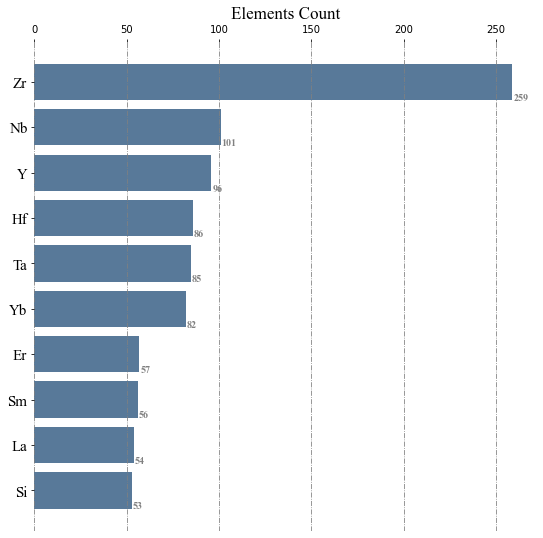

In [4]:
fig, ax = plt.subplots(figsize=(9, 9))
bar_color = [tuple([0.1803921568627451, 0.3411764705882353, 0.5019607843137255, 0.8])]

# Sort the cation dictionary by values in descending order and select the top ten elements
sorted_cation = {k: v for k, v in sorted(cation.items(), key=lambda item: item[1], reverse=True)[:10]}

ax.barh(list(sorted_cation.keys()), list(sorted_cation.values()), color=bar_color)
ax.invert_yaxis()

# Remove spines
for s in ['top', 'bottom', 'left', 'right']:
    ax.spines[s].set_visible(False)

# Remove tick marks
ax.xaxis.set_ticks_position('top')  # Change x-axis to the top

ax.xaxis.grid(True, linestyle='-.', which='major',
                   color='grey')
ax.yaxis.grid(False)
# Add value labels
for i in ax.patches:
    plt.text(i.get_width() + 0.5, i.get_y() + 0.8, str(round(i.get_width(), 2)),
             fontsize=10, fontweight='bold', color='grey', fontname='Times New Roman')
FP = FontProperties(family='Times New Roman', size=17)
plt.yticks(family='Times New Roman', size=15)

# Set title
ax.set_title('Elements Count', loc='center', fontproperties=FP)

# Set title position
title_pos = ax.title.get_position()
ax.title.set_position([title_pos[0], 2.05])  # Adjust the y-coordinate for the title

# Show plot
plt.show()

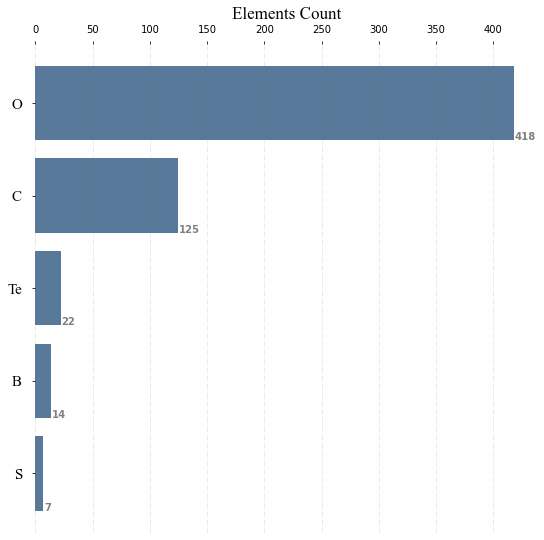

In [5]:
fig, ax = plt.subplots(figsize=(9, 9))
bar_color = [tuple([0.1803921568627451, 0.3411764705882353, 0.5019607843137255, 0.8])]

# Sort the anion dictionary by values in descending order and select all elements
sorted_anion = {k: v for k, v in sorted(anion.items(), key=lambda item: item[1], reverse=True)}

ax.barh(list(sorted_anion.keys()), list(sorted_anion.values()), color=bar_color)
ax.invert_yaxis()

# Remove spines
for s in ['top', 'bottom', 'left', 'right']:
    ax.spines[s].set_visible(False)

# Remove tick marks
ax.xaxis.set_ticks_position('top')  # Change x-axis to the top
ax.xaxis.set_tick_params(pad=5)
ax.yaxis.set_tick_params(pad=10)
ax.xaxis.grid(True, linestyle='-.', which='major', color='grey', alpha=0.2)
ax.yaxis.grid(False)

# Add value labels
for i in ax.patches:
    plt.text(i.get_width() + 0.5, i.get_y() + 0.8, str(round(i.get_width(), 2)),
             fontsize=10, fontweight='bold', color='grey')

# Set title
ax.set_title('Elements Count', loc='center', fontname='Times New Roman', size=17)
FP = FontProperties(family='Times New Roman', size=17)
plt.yticks(family='Times New Roman', size=15)

# Show plot
plt.show()

lowest T: 5.0 highest T: 2273.0


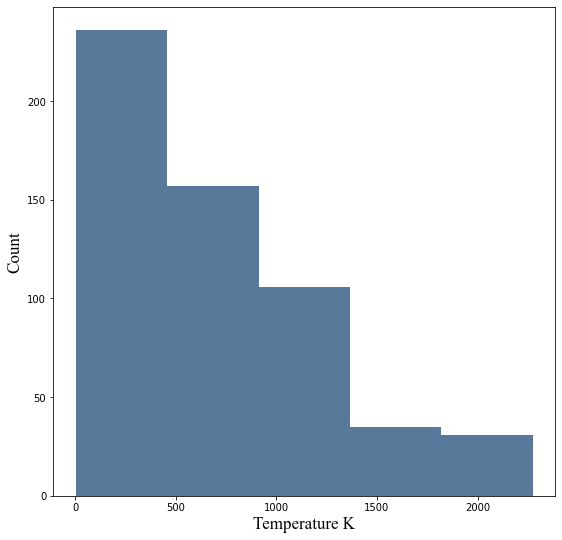

In [6]:
fig, ax = plt.subplots(figsize=(9, 9))
temperature_list= list(full_df['temperature'])
print('lowest T:', min(temperature_list), 'highest T:', max(temperature_list))
plt.hist(temperature_list, bins= 5, color=bar_color)
plt.xlabel("Temperature K", fontproperties=FP)
plt.ylabel("Count", fontproperties=FP)
plt.show()

In [7]:
# PC, VT on feattures
Before_Features =full_df.drop(['composition','thermal_conductivity', 'Class'], axis=1)
var_thres = VarianceThreshold(threshold=0.10)
var_thres.fit(Before_Features)
constant_columns = [column for column in Before_Features.columns if column not in Before_Features.columns[var_thres.get_support()]]
After_Variance = Before_Features.drop(constant_columns,axis=1)
After_Variance["ionic_radii"] = [k[0] for k in res]
af_corr = correlation(After_Variance, 0.90)

In [8]:
# Assuming you have a list of actual feature names
actual_feature_names = list(af_corr.columns)

# Create a dictionary to map the new feature names to the actual feature names
feature_mapping = {f'F{i+1}': actual_name for i, actual_name in enumerate(actual_feature_names)}

# Create a new dataframe with the updated feature names
new_data = af_corr[:]
new_data.columns = feature_mapping.keys()

# Create a table with the mapping of new feature names to actual feature names
table_data = {'New Feature Name': list(feature_mapping.keys()), 'Actual Feature Name': list(feature_mapping.values())}
table = pd.DataFrame(table_data)

In [ ]:
table.to_excel('datasets/feature_map.xlsx')

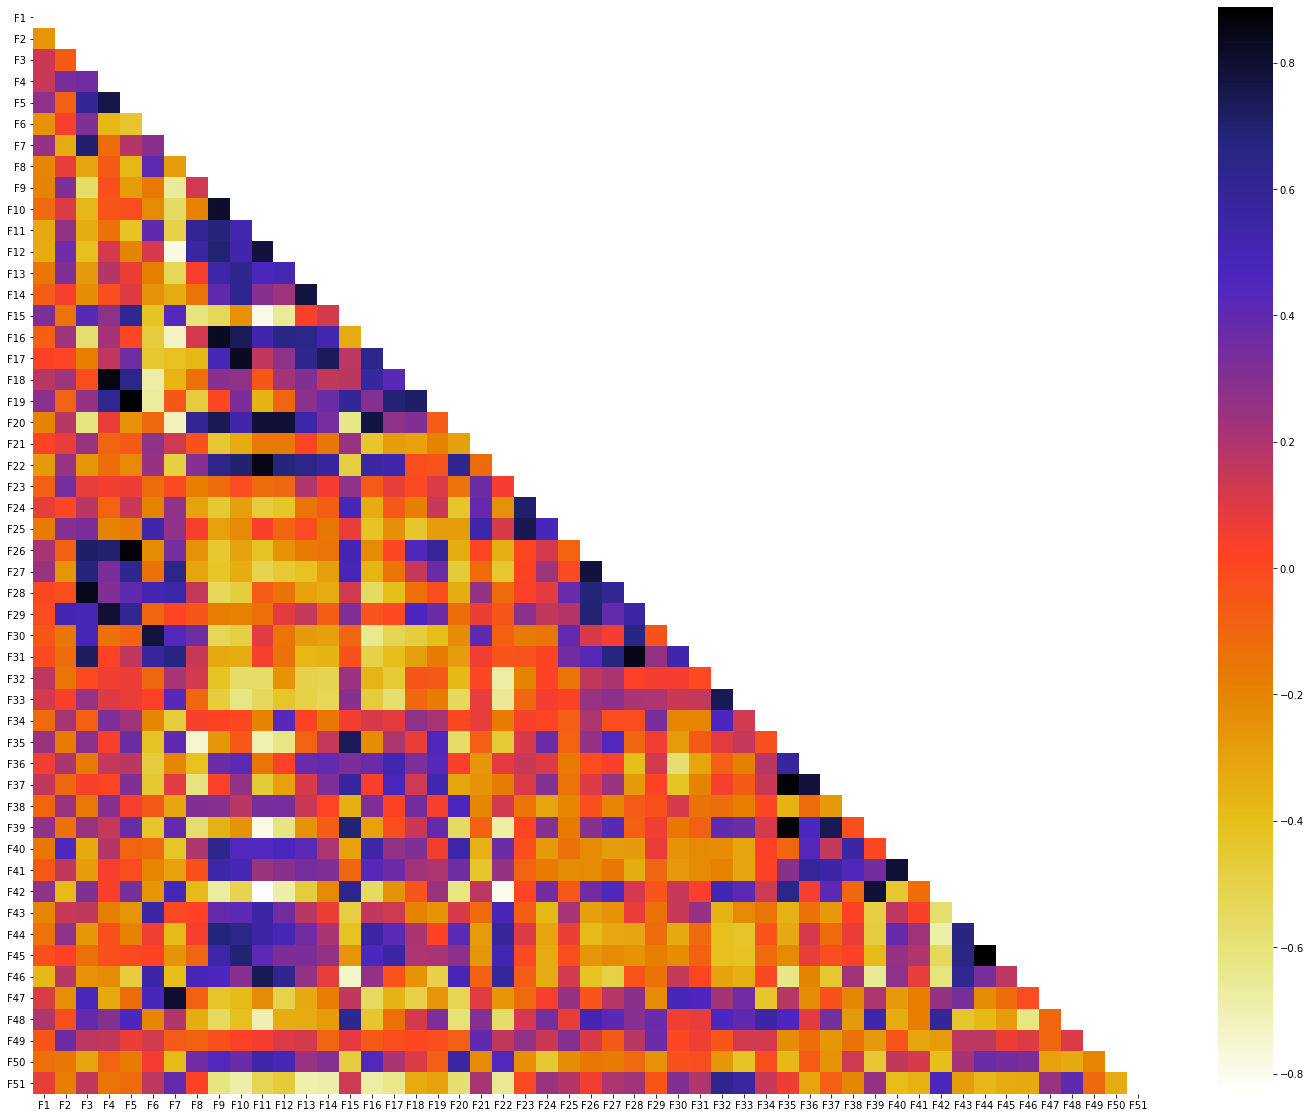

In [11]:
A_cor = new_data.corr()
plt.figure(figsize=(25, 20))
mask = np.triu(np.ones_like(A_cor, dtype=bool))
sns.heatmap(A_cor, cmap=plt.cm.CMRmap_r, annot=False, mask=mask)
plt.yticks(rotation=0) 
plt.show()

In [9]:
scaler = MinMaxScaler()
df1_scaled = scaler.fit_transform(af_corr)
df_scaled = pd.DataFrame(df1_scaled)
df_scaled.columns =af_corr.columns
Y= full_df['thermal_conductivity']
X= df_scaled
test_df_y = test_df['thermal_conductivity']
test_df = test_df[df_scaled.columns]
test_df_X = scaler.transform(test_df)

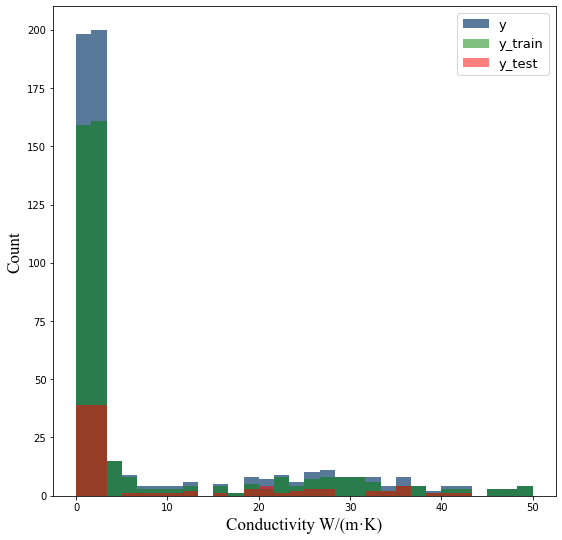

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df_scaled, Y, test_size=0.2, random_state=90)
Xdf = X_train
ydf = y_train

fig = plt.subplots(figsize=(9, 9))
# Plot histogram of conductivity_list
plt.hist(Y, bins=30, range=(0, 50), color=bar_color, label='y')

# Plot histogram of y_train
plt.hist(y_train, bins=30, range=(0, 50), color='g', alpha=0.5, label='y_train')

# Plot histogram of y_test
plt.hist(y_test, bins=30, range=(0, 50), color='r', alpha=0.5, label='y_test')

# Set x and y axis labels
FP = FontProperties(family='Times New Roman', size=17)
plt.xlabel("Conductivity W/(m·K)", fontproperties=FP)
plt.ylabel("Count", fontproperties=FP)

# Add legend
plt.legend(fontsize = 13)

# Show the plot
plt.show()

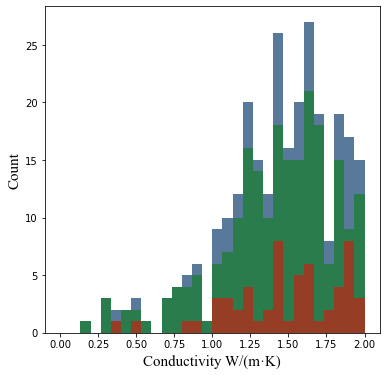

In [11]:
fig = plt.subplots(figsize=(6, 6))
# Plot histogram of conductivity_list
plt.hist(Y, bins=30, range=(0, 2), color=bar_color, label='y')

# Plot histogram of y_train
plt.hist(y_train, bins=30, range=(0, 2), color='g', alpha=0.5, label='y_train')

# Plot histogram of y_test
plt.hist(y_test, bins=30, range=(0, 2), color='r', alpha=0.5, label='y_test')

# Set x and y axis labels
FP = FontProperties(family='Times New Roman', size=12)
plt.xlabel("Conductivity W/(m·K)", family='Times New Roman', size=15)
plt.ylabel("Count", family='Times New Roman', size=15)



# Show the plot
plt.show()

In [15]:
rf_reg = rf()
rf_reg.fit(X_train,y_train)
rf_reg.score(X_test,y_test)
y_pred_rf = rf_reg.predict(X_test)
y_pred_train_rf = rf_reg.predict(X_train)
print('metrics on train sets: R2, MAE, RMSE:', metric(y_train, y_pred_train_rf))
print('metrics on test sets: R2, MAE, RMSE:', metric(y_test, y_pred_rf))
p = rf_reg.predict(test_df_X)
for k in p:
    print(k)

metrics on train sets: R2, MAE, RMSE: (0.9713745569627824, 1.0459968410099922, 2.583456310877779)
metrics on test sets: R2, MAE, RMSE: (0.9054356978436322, 1.5483660386126927, 3.8817697790311225)
1.419310174940706
1.4168388222728452
1.4010114770265627
1.399133699248785
1.3980374964803601
1.3980374964803601
1.5526948544050636
1.548458097195756
1.548949208306867
1.5250887513063058
1.516568175873923
1.5121930201234752
1.5116374645679196
1.5111683287654503
1.5102303121725424
1.5108275343947648
1.449542704605084
1.4470713519372234
1.4472888519372231
1.4252492585830452
1.4174615326130275
1.416780977057472
1.4162254215019165
1.4162254215019165
1.4162254215019165
1.416822643724139
1.9760366760779098
1.9752975811882079
1.9703563133356905
1.8956897119813578
1.8757461324774998
1.855793113769991
1.8530405096033244
1.851050540467522
1.8500349470331785
1.8506321692554009
1.43121640956278
1.428850656542185
1.428871397282926
1.405606936203881
1.3966694417153447
1.3951992573257994
1.3946437017702435
1.

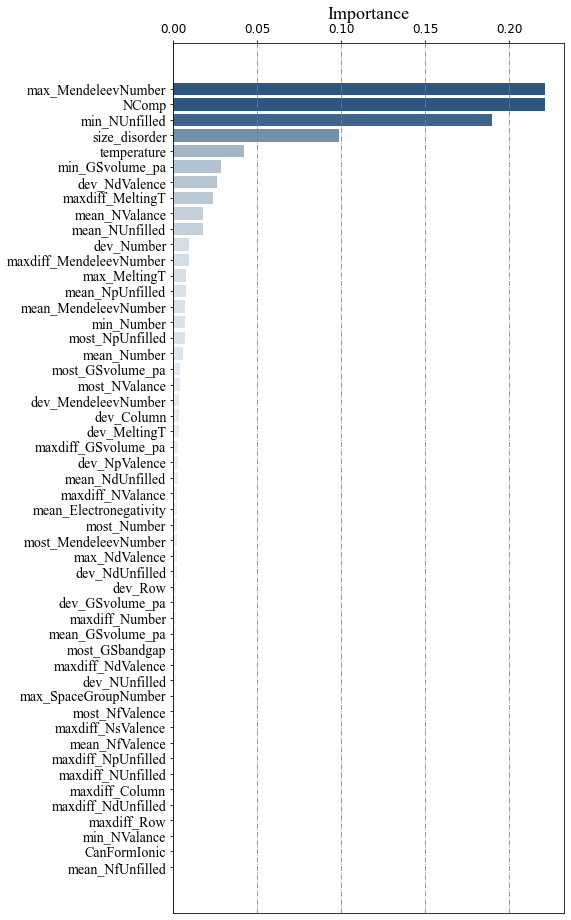

In [17]:
rf = rf_reg.best_estimator_
feature_importances = rf.feature_importances_
plot_feature_importance(feature_importances, Xdf)

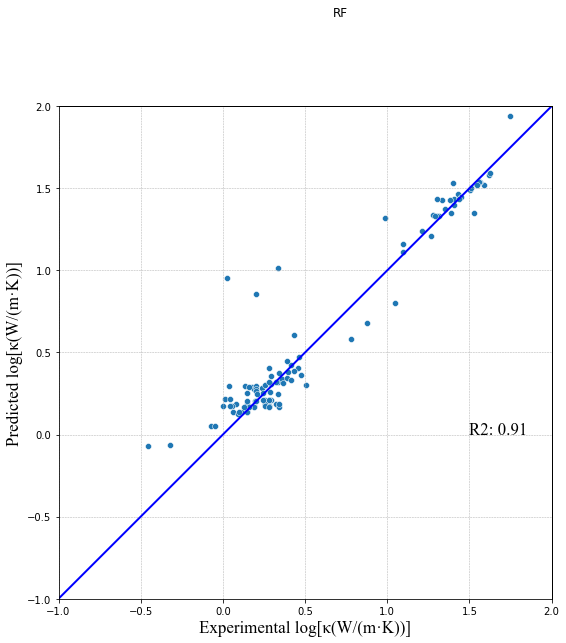

In [27]:
FP = FontProperties(family='Times New Roman', size=17)
y_pred_rf = rf_reg.predict(X_test)
y_test_log = np.log10(y_test)
y_pred_rf_log = np.log10(y_pred_rf)

e = sns.jointplot(x=y_test_log, y=y_pred_rf_log, kind='scatter', xlim=(-1, 2), ylim=(-1, 2), height=9)
e.fig.suptitle("RF")
e.ax_joint.plot([-1, 2], [-1, 2], 'b-', linewidth=2)
e.ax_joint.set_xlabel('Experimental log[κ(W/(m·K))]', fontproperties=FP)
e.ax_joint.set_ylabel('Predicted log[κ(W/(m·K))]', fontproperties=FP)

# Remove axis histograms
e.ax_marg_x.remove()
e.ax_marg_y.remove()

# Add a grid
e.ax_joint.grid(True, linestyle='--', linewidth=0.5)
e.ax_joint.spines['top'].set_linewidth(1)
e.ax_joint.spines['right'].set_linewidth(1)

# Add R2 score annotation

e.ax_joint.text(1.5, 0, 'R2: 0.91', fontproperties=FP)
e.ax_joint.spines['top'].set_visible(True)
e.ax_joint.spines['right'].set_visible(True)

# Show the plot
plt.show()

In [22]:
# krr model
krr = krr()
krr.fit(X_train, y_train)
y_pred_krr = krr.predict(X_test)
y_pred_train_krr = krr.predict(X_train)
print('metrics on train sets: R2, MAE, RMSE:', metric(y_train, y_pred_train_krr))
print('metrics on test sets: R2, MAE, RMSE:', metric(y_test, y_pred_krr))
p = krr.predict(test_df_X)
for k in p:
    print(k)

metrics on train sets: R2, MAE, RMSE: (0.9956334315252053, 0.30690129164298874, 1.0090092567937916)
metrics on test sets: R2, MAE, RMSE: (0.9035291184816895, 1.1049287450228829, 3.9207060881084588)
1.7138348709615343
1.7531610413536214
1.8064294817738187
1.87531352783202
1.9688785696078526
2.094621460638052
2.2967634071596734
2.1822890797854626
2.0490502052874575
1.9276471825321835
1.818920720190846
1.7235887225445197
1.6422398110025966
1.5753282598232659
1.52317039655793
1.485942499109953
1.3594862639335545
1.238125416614949
1.0999654060809192
0.9777084336902035
0.8721348482399733
0.7838732005714633
0.7133953736654775
0.6610133834216825
0.6268778656056355
0.610978243842645
1.7021180493247812
1.520927373171844
1.3146019974140017
1.1324008199028412
0.9759645732412991
0.8467028737395594
0.7457785511975317
0.6740946574204827
0.6322843296362066
0.6207036476428129
2.7618044316226076
2.6694907445751426
2.5653382673266947
2.47449589725602
2.397720878121447
2.3356337049050637
2.288712056931587

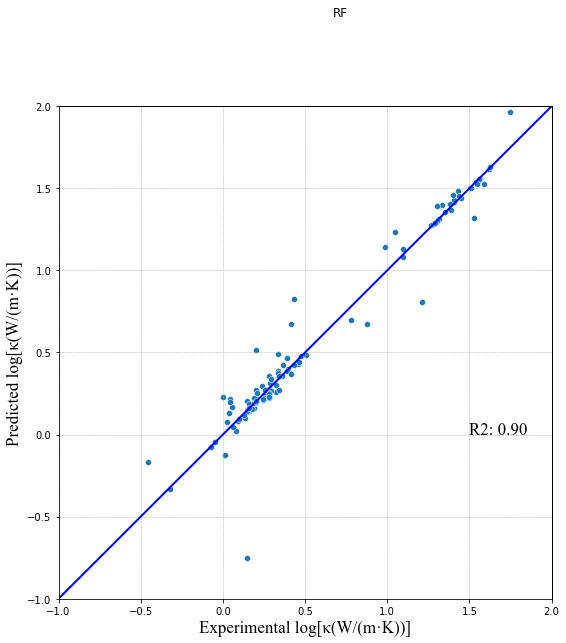

In [28]:
# plot the prediction vs experiment
y_test_log = np.log10(y_test)
y_pred_krr_log = np.log10(y_pred_krr)
e = sns.jointplot(x=y_test_log, y=y_pred_krr_log, kind='scatter', xlim=(-1, 2), ylim=(-1, 2), height=9)
e.fig.suptitle("RF")
e.ax_joint.plot([-1, 2], [-1, 2], 'b-', linewidth=2)
e.ax_joint.set_xlabel('Experimental log[κ(W/(m·K))]', fontproperties=FP)
e.ax_joint.set_ylabel('Predicted log[κ(W/(m·K))]', fontproperties=FP)

# Remove axis histograms
e.ax_marg_x.remove()
e.ax_marg_y.remove()

# Add a grid
e.ax_joint.grid(True, linestyle='--', linewidth=0.5)
e.ax_joint.spines['top'].set_linewidth(1)
e.ax_joint.spines['right'].set_linewidth(1)

# Add R2 score annotation
e.ax_joint.text(1.5, 0, 'R2: 0.90', fontproperties=FP)
e.ax_joint.spines['top'].set_visible(True)
e.ax_joint.spines['right'].set_visible(True)

# Show the plot
plt.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   37.3s finished


metrics on train sets: R2, MAE, RMSE: (0.99518875224783, 0.5374299381734652, 1.0591412279592967)
metrics on test sets: R2, MAE, RMSE: (0.9102230933356171, 1.2860757747552303, 3.7822347654471686)
2.2936509
1.8708518
1.9158037
1.9017123
2.0721455
2.0590515
2.3114622
1.8750991
1.891799
1.8960979
1.8960979
1.8960979
1.8820063
1.8820063
2.0524397
2.0524397
1.8477848
1.3792428
1.4190066
1.4639586
1.4639586
1.4639586
1.4498672
1.4498672
1.6203024
1.6203024
3.147866
2.676048
2.8173144
2.9746466
2.9746466
2.9746466
2.960555
2.960555
3.1309893
3.1309893
3.0196483
2.5445
2.6857665
2.6900644
2.6900644
2.6900644
2.675973
2.675973
2.8464072
2.8464072
2.3737977
1.8986495
1.9153496
1.9196484
1.9196484
1.9196484
1.9055568
1.9055568
2.07599
2.07599
2.6625888
2.241273
3.0844843
5.16696
5.8677807
7.241584
7.918809
8.262975


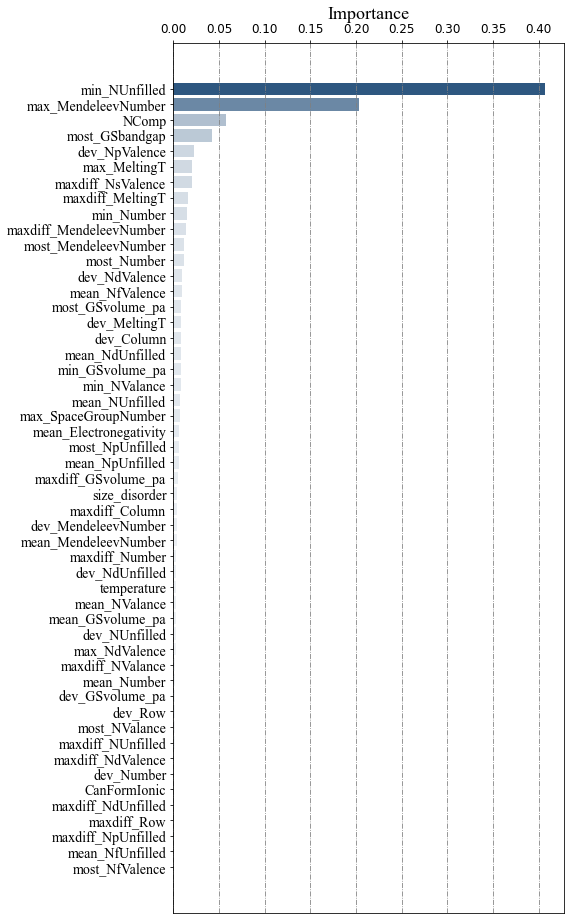

In [29]:
#xgb model
xgb_model = xgb_model()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_train_xgb = xgb_model.predict(X_train)
print('metrics on train sets: R2, MAE, RMSE:', metric(y_train, y_pred_train_xgb))
print('metrics on test sets: R2, MAE, RMSE:', metric(y_test, y_pred_xgb))
p = xgb_model.predict(test_df_X)
for k in p:
    print(k)
xgb_model = xgb_model.best_estimator_
feature_importances = xgb_model.feature_importances_
plot_feature_importance(feature_importances, Xdf)

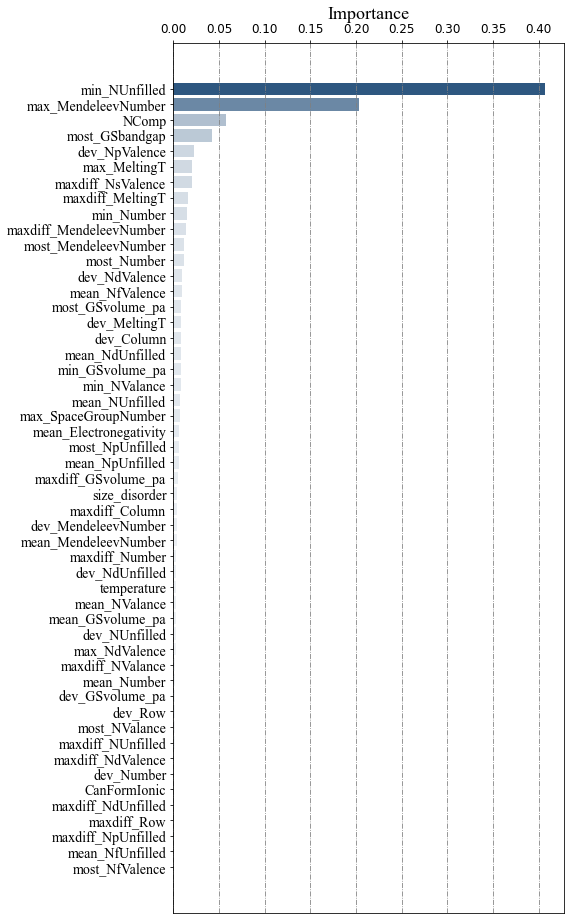

In [85]:
feature_importances = xgb_model.feature_importances_
plot_feature_importance(feature_importances, Xdf)

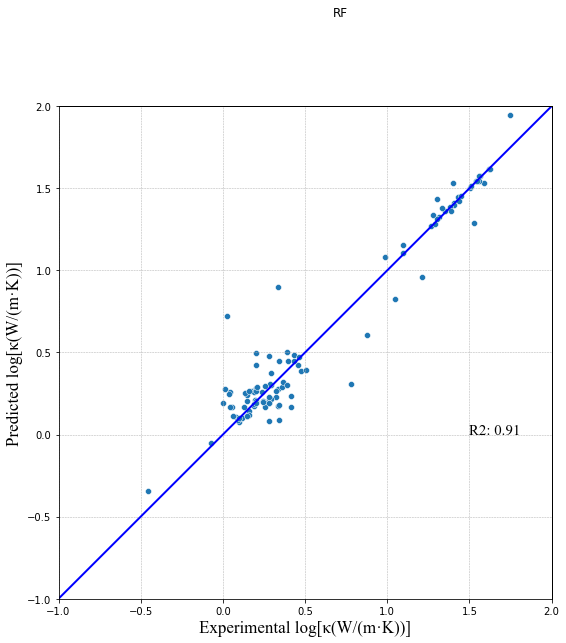

In [31]:
y_test_log = np.log10(y_test)
y_pred_xgb_log = np.log10(y_pred_xgb)
FP = FontProperties(family='Times New Roman', size=17)
e = sns.jointplot(x=y_test_log, y=y_pred_xgb_log, kind='scatter', xlim=(-1, 2), ylim=(-1, 2), height=9)
e.fig.suptitle("RF")
e.ax_joint.plot([-1, 2], [-1, 2], 'b-', linewidth=2)
e.ax_joint.set_xlabel('Experimental log[κ(W/(m·K))]', fontproperties=FP)
e.ax_joint.set_ylabel('Predicted log[κ(W/(m·K))]', fontproperties=FP)

# Remove axis histograms
e.ax_marg_x.remove()
e.ax_marg_y.remove()

# Add a grid
e.ax_joint.grid(True, linestyle='--', linewidth=0.5)
e.ax_joint.spines['top'].set_linewidth(1)
e.ax_joint.spines['right'].set_linewidth(1)

# Add R2 score annotation
e.ax_joint.text(1.5, 0, 'R2: 0.91', fontsize=15, family='Times New Roman')
e.ax_joint.spines['top'].set_visible(True)
e.ax_joint.spines['right'].set_visible(True)

# Show the plot
plt.show()

In [13]:
#svr model
svr = svr()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
y_pred_train_svr = svr.predict(X_train)
print('metrics on train sets: R2, MAE, RMSE:', metric(y_train, y_pred_train_svr))
print('metrics on test sets: R2, MAE, RMSE:', metric(y_test, y_pred_svr))
print(svr.predict(test_df_X))
# plot the prediction vs experiment

metrics on train sets: R2, MAE, RMSE: (0.6258331237524918, 3.139520373212395, 9.340232396596098)
metrics on test sets: R2, MAE, RMSE: (0.8169573902605416, 2.511104025645768, 5.400603121923784)
[ 3.05536877  3.08500282  3.14132535  3.22009194  3.32157596  3.44444804
  2.41561401  2.39072086  2.3650657   2.34554569  2.33221705  2.32511932
  2.32427518  2.32969032  2.34135341  2.35923614  1.9494488   1.930188
  1.91197789  1.90033556  1.89529794  1.89688417  1.90509545  1.91991503
  1.94130827  1.9692228   4.63049393  4.64354044  4.66409494  4.68933212
  4.71920072  4.75363579  4.79255888  4.83587834  4.88348968  4.935276
  3.32498654  3.31354489  3.30413526  3.30019211  3.30173377  3.30876345
  3.32126919  3.33922388  3.36258539  3.39129667  2.67930124  2.66418893
  2.65070174  2.64325857  2.64188705  2.64659811  2.65738593  2.67422795
  2.69708488  2.72590094 16.53159432 16.71248921 16.88921073 17.06133924
 17.22846221 17.3901758  17.54608652 17.69581284]


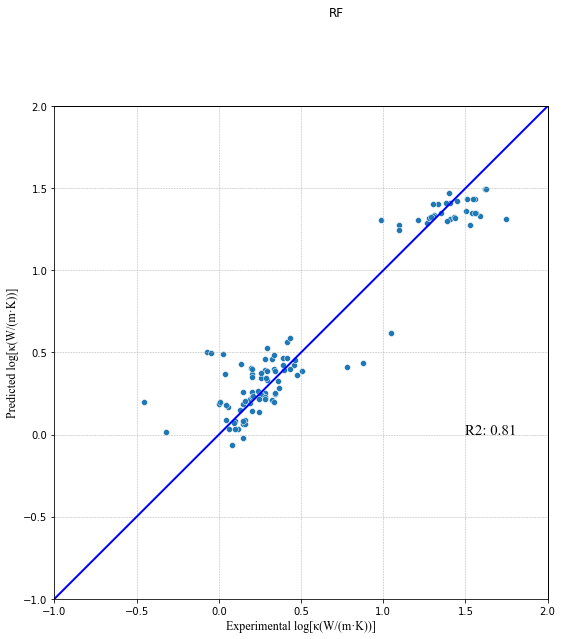

In [17]:
y_test_log = np.log10(y_test)
y_pred_svr_log = np.log10(y_pred_svr)
e = sns.jointplot(x=y_test_log, y=y_pred_svr_log, kind='scatter', xlim=(-1, 2), ylim=(-1, 2), height=9)
e.fig.suptitle("RF")
e.ax_joint.plot([-1, 2], [-1, 2], 'b-', linewidth=2)
e.ax_joint.set_xlabel('Experimental log[κ(W/(m·K))]', fontproperties=FP)
e.ax_joint.set_ylabel('Predicted log[κ(W/(m·K))]', fontproperties=FP)

# Remove axis histograms
e.ax_marg_x.remove()
e.ax_marg_y.remove()

# Add a grid
e.ax_joint.grid(True, linestyle='--', linewidth=0.5)
e.ax_joint.spines['top'].set_linewidth(1)
e.ax_joint.spines['right'].set_linewidth(1)

# Add R2 score annotation
e.ax_joint.text(1.5, 0, 'R2: 0.81',  fontsize=15, family='Times New Roman')
e.ax_joint.spines['top'].set_visible(True)
e.ax_joint.spines['right'].set_visible(True)

# Show the plot
plt.show()

In [44]:
pred_df = pd.read_excel('./datasets/prediction300.xlsx')

In [74]:
pred_df_filtered = pred_df[pred_df['ionic_radii'] < 0.9]
compositions = pred_df_filtered['compositions']
disorder = pred_df_filtered['ionic_radii']
max_Men = pred_df_filtered['max_MendeleevNumber']
min_NUn = pred_df_filtered['min_NUnfilled']
N_com = pred_df_filtered['NComp']
pred_df1 = pred_df_filtered[df_scaled.columns]
pred_df_X = scaler.transform(pred_df1)
predictions = xgb_model.predict(pred_df_X)

In [62]:
element_counter = collections.Counter()
for c in compositions:
    elements, _ = decompose_formula_II(c)
    element_count = len(elements)
    element_counter[element_count] += 1
print(element_counter)

Counter({7: 10764, 6: 7189, 5: 4213, 4: 1624, 3: 389})


In [63]:
for c, p in zip(compositions, predictions):
    if p < 0.1 and p > 0:
        print(p)

0.03681089
0.012021139
0.05858345
0.032298632
0.032298632
0.05854667
0.031780656
0.045308236
0.061305515


In [64]:
for c, p in zip(compositions, predictions):
    if p < 1 and p > 0:
        print(c)

ZrTaO10
ZrYbO10
ZrSmTe10
ZrTiO10
ZrNdTe10
ZrCuTe10
NbGdO10
NbBaTe10
NbScO10
NbScTe10
YHfTe10
YTaO10
YCuO10
YCuTe10
HfTaO10
HfYbTe10
HfErO10
HfErTe10
HfDyTe10
HfGdTe10
HfBaTe10
TaErO10
TaDyO10
TaGdO10
YbTiO10
YbCuO10
ErTiO10
SmCuO10
DyTiO10
DyCuTe10
GdCuTe10
BaNdTe10
NdCuO10
ScCuTe10
ZrNbYTe10
ZrNbHfO10
ZrNbSmTe10
ZrNbEuTe10
ZrNbScO10
ZrHfTaO10
ZrHfYbTe10
ZrHfTiO10
ZrHfScO10
ZrHfCuO10
ZrYbTiO10
ZrYbScTe10
ZrYbCuO10
ZrSmCuO10
ZrLaCuTe10
ZrDyGdTe10
ZrDyTiO10
ZrDyScTe10
ZrGdTiO10
ZrGdScTe10
ZrTiCuO10
ZrLaCuTe10
ZrNdCuO10
NbYScTe10
NbHfErTe10
NbHfSmTe10
NbHfLaTe10
NbHfDyTe10
NbHfEuTe10
NbHfGdTe10
NbHfTiO10
NbHfLaTe10
NbHfCuTe10
NbTaScO10
NbErScO10
NbErCuO10
NbSmTiO10
NbDyScO10
NbEuTiO10
NbGdScO10
NbGdCuO10
NbGdCuTe10
NbScCuO10
YHfTiO10
YHfScO10
YErLaTe10
YErDyTe10
YErGdTe10
YErLaTe10
YErNdTe10
YSmDyTe10
YSmGdTe10
YSmNdTe10
YSmCuTe10
YLaGdTe10
YDyEuTe10
YDyNdTe10
YGdLaTe10
YGdCuTe10
YBaCuTe10
HfTaScO10
HfTaCuO10
HfYbScTe10
HfErScTe10
HfErCuO10
HfTiCuO10
TaYbCuO10
TaErCuO10
TaSmCuO10
TaDyCuO1

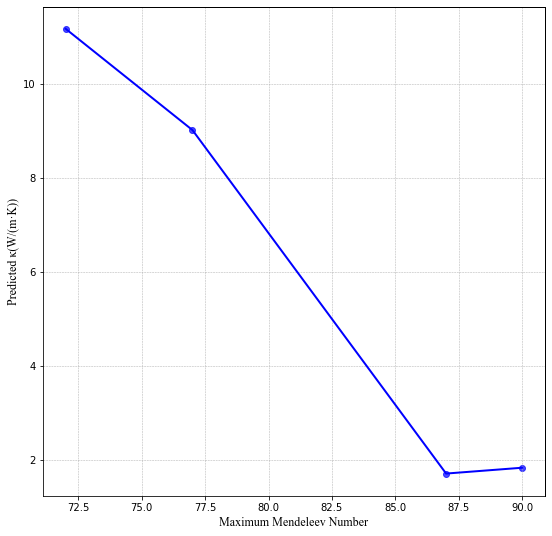

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
import collections

# Set the figure size
plt.figure(figsize=(9, 9))

# Iterate over the elements in the lists
max_Men_dict = collections.defaultdict(list)
# Iterate over the elements in the lists
for c, i, p in zip(compositions, max_Men, predictions):
    # Decompose the formula using the decompose_formula_II function
    elements, _ = decompose_formula_II(c)
    element_count = len(elements)
    # Plot the scatter for each group
    if p > 0:
        max_Men_dict[i].append(p)

# Create an empty list to store the scatter plot colors
scatter_colors = []

# Iterate over the max_Men_dict items and plot the scatter for each group
for key, l in max_Men_dict.items():
    # Compute the average prediction for each group
    avg_prediction = sum(l) / len(l)
    # Plot the scatter for each group with a specific color
    scatter = plt.scatter(key, avg_prediction, alpha=0.7, color='blue')
    # Add the scatter color to the list
# Add labels and legend
plt.xlabel('Maximum Mendeleev Number', fontproperties=FP)
plt.ylabel('Predicted κ(W/(m·K))', fontproperties=FP)
# Sort the max_Men_dict by keys
sorted_max_Men = sorted(max_Men_dict.keys())
# Create a list of average predictions sorted by keys
avg_predictions = [sum(max_Men_dict[k]) / len(max_Men_dict[k]) for k in sorted_max_Men]

# Add lines
plt.plot(sorted_max_Men, avg_predictions, 'b-', linewidth=2)
# Add a grid
plt.grid(True, linestyle='--', linewidth=0.5)
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(1)

# Show the plot
plt.show()

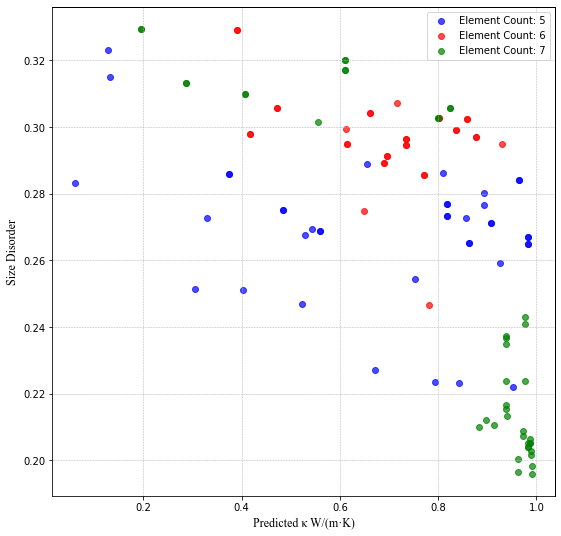

In [78]:
plt.figure(figsize=(9, 9))

# Define the element counts for the legend
legend_element_counts = [5, 6, 7]

# Define the colors for the element counts
colors = ['blue', 'red', 'green']

# Create an empty list to store the scatter plot handles and labels
scatter_handles = []
scatter_labels = []

# Iterate over the elements in the lists
for c, i, p in zip(compositions, disorder, predictions):
    # Decompose the formula using the decompose_formula_II function
    elements, _ = decompose_formula_II(c)
    element_count = len(elements)
    
    # Plot the scatter for each group
    if element_count in legend_element_counts and 0 < p < 1:
        # Get the index of the current element count in the legend list
        index = legend_element_counts.index(element_count)
        
        # Check if the current element count is not added to the legend yet
        if element_count not in scatter_labels:
            color = colors[index]
            scatter = plt.scatter(p, i, alpha=0.7, color=color, label=f'Element Count: {element_count}')
            scatter_handles.append(scatter)
            scatter_labels.append(element_count)
        else:
            # Find the index of the element count in the legend_labels list
            legend_index = scatter_labels.index(element_count)
            color = colors[legend_index]
            plt.scatter(p, i, alpha=0.7, color=color)

# Add labels and legend
plt.xlabel('Predicted κ W/(m·K)', fontproperties=FP)
plt.ylabel('Size Disorder', fontproperties=FP)
plt.legend(handles=scatter_handles, loc='best')

# Add a grid
plt.grid(True, linestyle='--', linewidth=0.5)
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(1)

# Show the plot
plt.show()

<ipython-input-76-c2890a57d2fd>:36: UserWarning: Legend does not support array([0. , 0. , 1. , 0.7]) instances.
A proxy artist may be used instead.
See: https://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  plt.legend(scatter_colors, num_dict.keys())


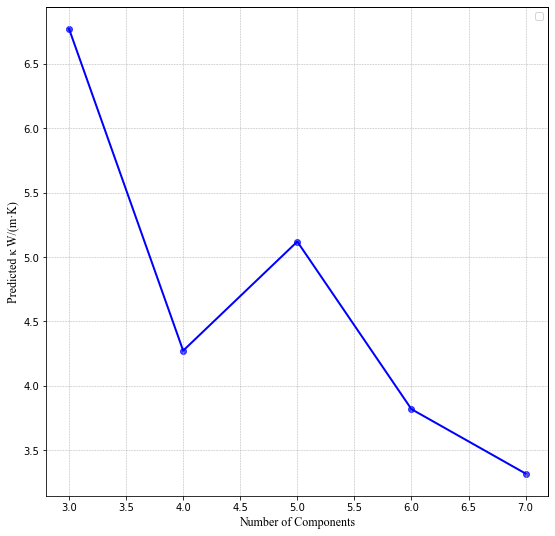

In [76]:
plt.figure(figsize=(9, 9))

num_dict = collections.defaultdict(list)
# Iterate over the elements in the lists
for c, i, p in zip(compositions, N_com, predictions):
    # Decompose the formula using the decompose_formula_II function
    elements, _ = decompose_formula_II(c)
    element_count = len(elements)
    # Plot the scatter for each group
    if p > 0 and i <= 8:
        num_dict[i].append(p)

# Create an empty list to store the scatter plot colors
scatter_colors = []

# Iterate over the num_dict items and plot the scatter for each group
for key, l in num_dict.items():
    # Compute the average prediction for each group
    avg_prediction = sum(l) / len(l)
    # Plot the scatter for each group with a specific color
    scatter = plt.scatter(key, avg_prediction, alpha=0.7, color='blue')
    # Add the scatter color to the list
    scatter_colors.append(scatter.get_facecolor()[0])

# Sort the num_dict by keys
sorted_N_com = sorted(num_dict.keys())
# Create a list of average predictions sorted by keys
avg_predictions = [sum(num_dict[k]) / len(num_dict[k]) for k in sorted_N_com]

# Add lines
plt.plot(sorted_N_com, avg_predictions, 'b-', linewidth=2)

# Add labels and legend
plt.xlabel('Number of Components', fontproperties=FP)
plt.ylabel('Predicted κ W/(m·K)', fontproperties=FP)
plt.legend(scatter_colors, num_dict.keys())

# Add a grid
plt.grid(True, linestyle='--', linewidth=0.5)
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(1)

# Show the plot
plt.show()

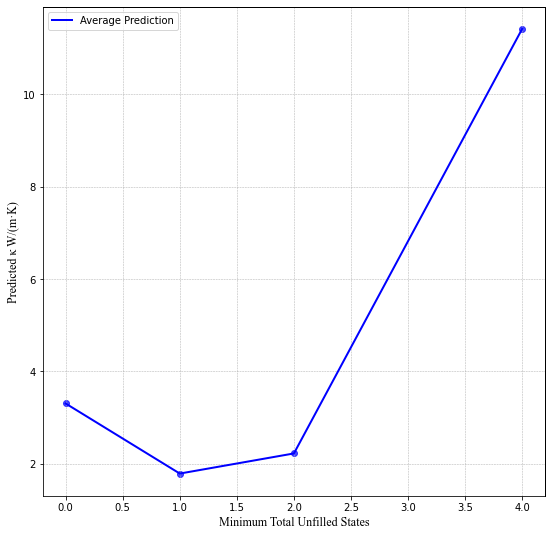

In [77]:
plt.figure(figsize=(9, 9))

min_NUn_dict = collections.defaultdict(list)
# Iterate over the elements in the lists
for c, i, p in zip(compositions, min_NUn, predictions):
    # Decompose the formula using the decompose_formula_II function
    elements, _ = decompose_formula_II(c)
    element_count = len(elements)
    # Plot the scatter for each group
    if p > 0:
        min_NUn_dict[i].append(p)

# Create an empty list to store the scatter plot colors
scatter_colors = []

# Iterate over the min_NUn_dict items and plot the scatter for each group
for key, l in min_NUn_dict.items():
    # Compute the average prediction for each group
    avg_prediction = sum(l) / len(l)
    # Plot the scatter for each group with a specific color
    scatter = plt.scatter(key, avg_prediction, alpha=0.7, color='blue')
    # Add the scatter color to the list
    scatter_colors.append(scatter.get_facecolor()[0])

# Sort the min_NUn_dict by keys
sorted_min_NUn = sorted(min_NUn_dict.keys())
# Create a list of average predictions sorted by keys
avg_predictions = [sum(min_NUn_dict[k]) / len(min_NUn_dict[k]) for k in sorted_min_NUn]

# Add lines
plt.plot(sorted_min_NUn, avg_predictions, 'b-', linewidth=2)

# Add labels and legend
plt.xlabel('Minimum Total Unfilled States', fontproperties=FP)
plt.ylabel('Predicted κ W/(m·K)', fontproperties=FP)

# Add a legend
plt.legend(['Average Prediction'])

# Add a grid
plt.grid(True, linestyle='--', linewidth=0.5)
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(1)

# Show the plot
plt.show()

Reproduce the recently published work

In [7]:
data_test = pd.read_excel('./datasets/test_set.xlsx')

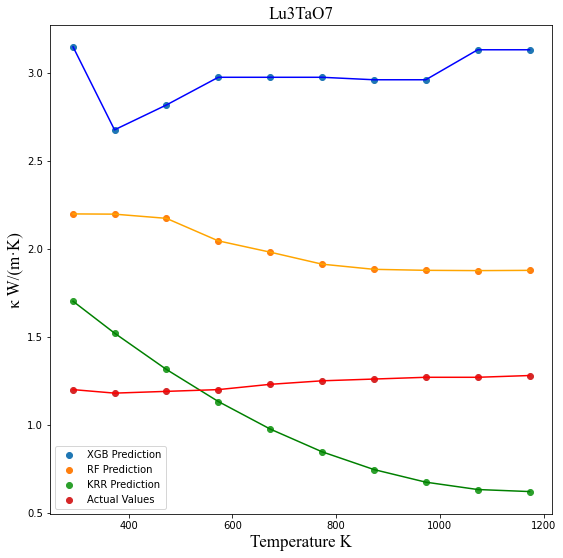

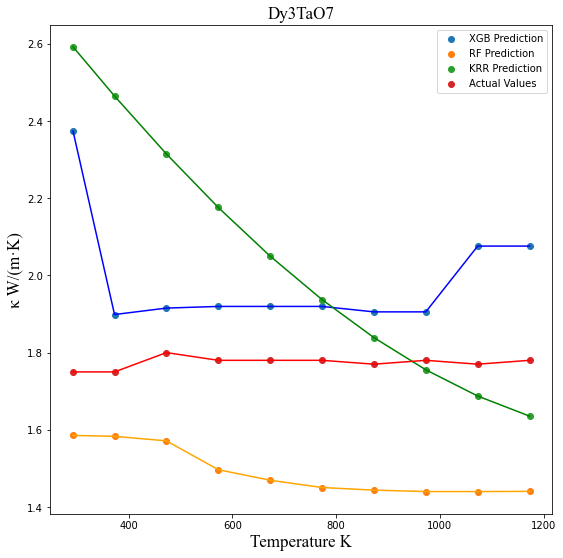

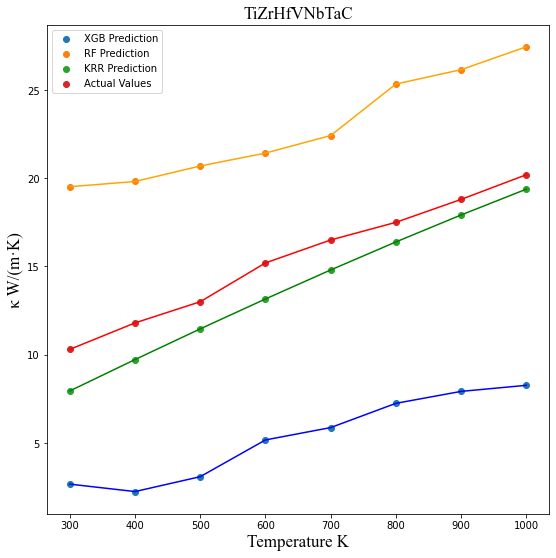

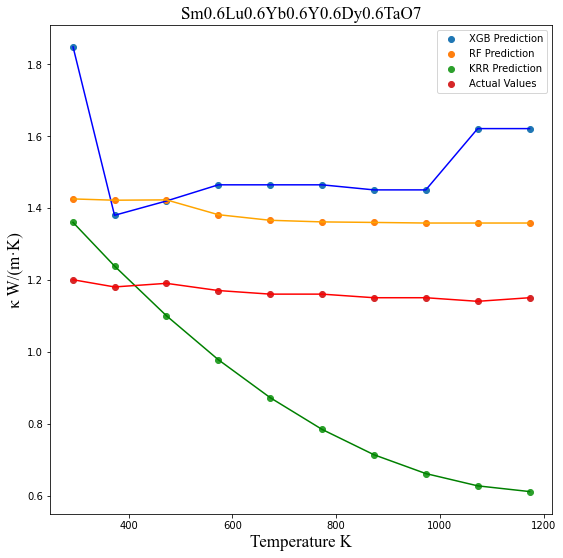

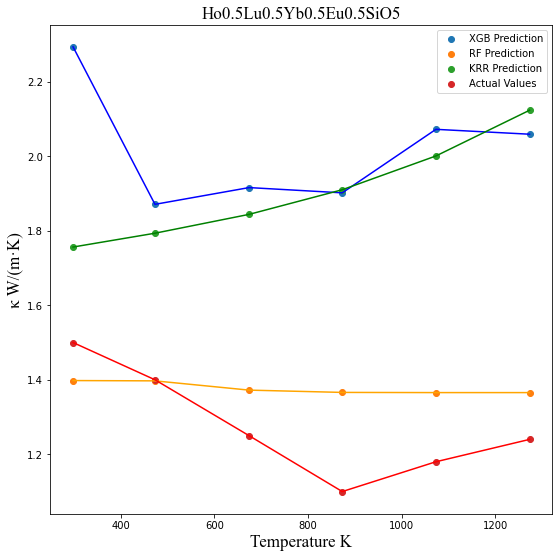

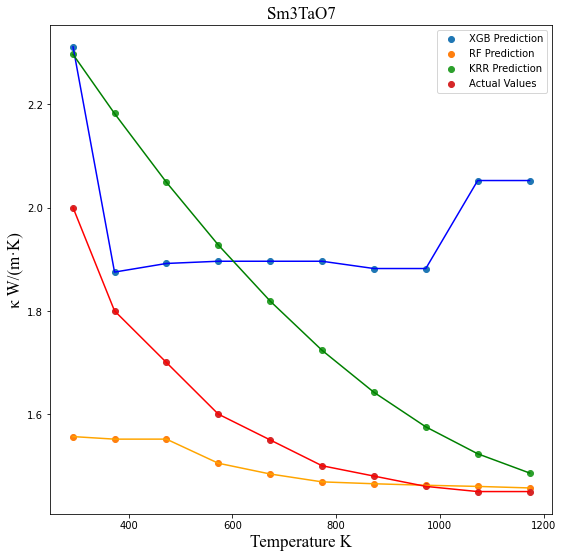

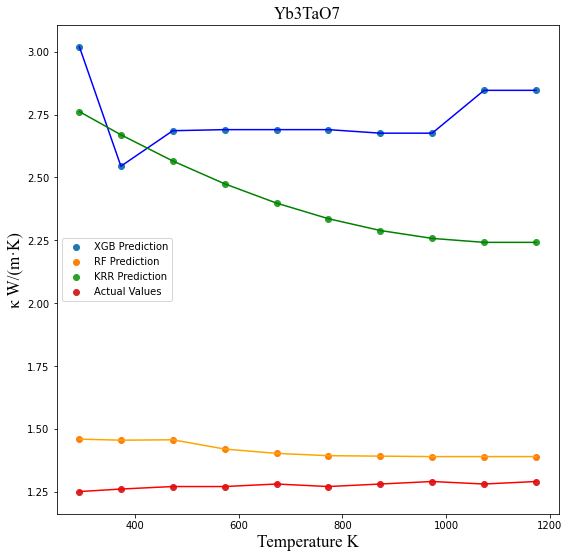

In [9]:
FP = FontProperties(family='Times New Roman', size=17)
compositions_test = data_test['composition']

# Iterate over the compositions
for composition in set(compositions_test):
    plt.figure(figsize=(9, 9))
    # Filter the data for the current composition
    composition_data = data_test[data_test['composition'] == composition]
    
    # Extract the values for each prediction model and actual values
    xgb_predictions = composition_data['xgb_prediction']
    rf_predictions = composition_data['rf_prediction']
    krr_predictions = composition_data['krr_prediction']
    actual_values = composition_data['thermal_conductivity']
    temperature = composition_data['temperature']
    
    # Plot scatter dots for each prediction model and actual values
    plt.scatter(temperature, xgb_predictions, label='XGB Prediction')
    plt.scatter(temperature, rf_predictions, label='RF Prediction')
    plt.scatter(temperature, krr_predictions, label='KRR Prediction')
    plt.scatter(temperature, actual_values, label='Actual Values')
    
    # Connect the scatter dots with lines
    plt.plot(temperature, xgb_predictions, linestyle='-', color='blue')
    plt.plot(temperature, rf_predictions, linestyle='-', color='orange')
    plt.plot(temperature, krr_predictions, linestyle='-', color='green')
    plt.plot(temperature, actual_values, linestyle='-', color='red')
    
    # Add labels and legend for each composition
    plt.xlabel('Temperature K', fontproperties=FP)
    plt.ylabel('κ W/(m·K)', fontproperties=FP)
    plt.title(f'{composition}', fontproperties=FP)
    plt.legend()
    
    # Show the plot for each composition
    plt.show()


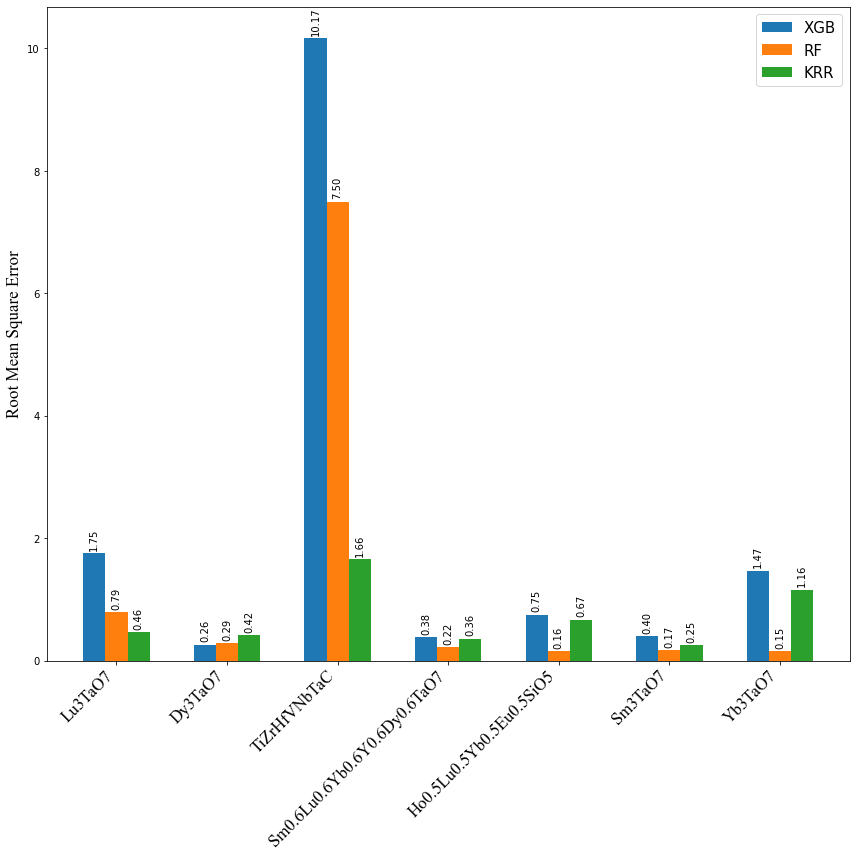

In [29]:
import math
# Create empty lists to store the RMSE values for each model
xgb_rmse_list = []
rf_rmse_list = []
krr_rmse_list = []
composition_labels = []

# Iterate over the compositions
for composition in set(compositions_test):
    # Filter the data for the current composition
    composition_data = data_test[data_test['composition'] == composition]

    # Extract the values for each prediction model and actual values
    xgb_predictions = composition_data['xgb_prediction']
    rf_predictions = composition_data['rf_prediction']
    krr_predictions = composition_data['krr_prediction']
    actual_values = composition_data['thermal_conductivity']

    # Calculate the RMSE for each model
    xgb_rmse = np.sqrt(np.mean((actual_values - xgb_predictions) ** 2))
    rf_rmse = np.sqrt(np.mean((actual_values - rf_predictions) ** 2))
    krr_rmse = np.sqrt(np.mean((actual_values - krr_predictions) ** 2))

    # Append the RMSE values to the corresponding lists
    xgb_rmse_list.append(round(xgb_rmse, 2))
    rf_rmse_list.append(round(rf_rmse, 2))
    krr_rmse_list.append(round(krr_rmse, 2))
    
    # Append the composition name to the labels list
    composition_labels.append(composition)

# Create a bar chart to show the RMSE values for each composition and model
x = np.arange(len(composition_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 12))
rects1 = ax.bar(x - width, xgb_rmse_list, width, label='XGB')
rects2 = ax.bar(x, rf_rmse_list, width, label='RF')
rects3 = ax.bar(x + width, krr_rmse_list, width, label='KRR')

ax.set_ylabel('Root Mean Square Error', fontproperties=FP)
ax.set_xticks(x)
ax.set_xticklabels(composition_labels, rotation=45, ha='right', fontproperties=FP) # Rotate and align the labels
ax.legend(fontsize=15)

# Add the RMSE values as text labels on top of each bar with adjusted alignment
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', rotation=90) # Rotate the RMSE values

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

Anion Content Impacts

In [100]:
data_test = pd.read_excel('./datasets/krr.xlsx')

In [101]:
data_test

,composition,krr_prediction,thermal_conductivity,temperature
0,TiZrHfVNbTaC0.6,7.662966,6.5,300
1,TiZrHfVNbTaC0.6,9.109016,7.0,400
2,TiZrHfVNbTaC0.6,10.529144,8.0,500
3,TiZrHfVNbTaC0.6,11.917310,9.0,600
4,TiZrHfVNbTaC0.6,13.267836,10.0,700
5,TiZrHfVNbTaC0.6,14.575441,11.0,800
6,TiZrHfVNbTaC0.6,15.835275,12.0,900
7,TiZrHfVNbTaC0.6,17.042949,13.0,1000
8,TiZrHfVNbTaC0.71,7.931659,7.0,300
9,TiZrHfVNbTaC0.71,9.446350,7.4,400


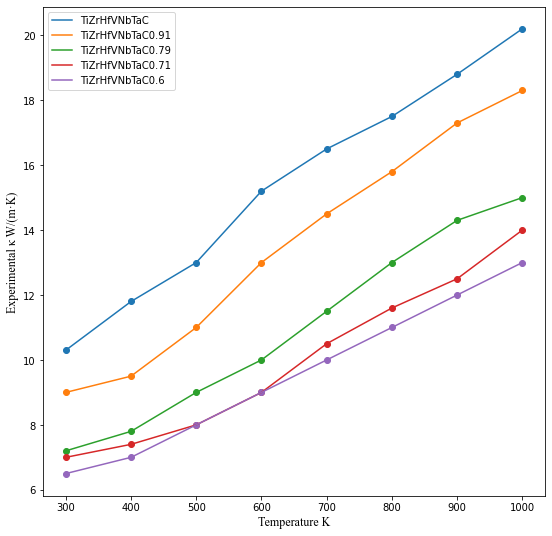

In [103]:
composition_order = ['TiZrHfVNbTaC', 'TiZrHfVNbTaC0.91', 'TiZrHfVNbTaC0.79', 'TiZrHfVNbTaC0.71', 'TiZrHfVNbTaC0.6']
plt.figure(figsize=(9, 9))
# Iterate over the compositions in the desired order
for composition in composition_order:
    
    # Filter the data for the current composition
    composition_data = data_test[data_test['composition'] == composition]
    
    # Extract the values for actual thermal conductivity and temperature
    actual_values = composition_data['thermal_conductivity']
    temperature = composition_data['temperature']
    plt.scatter(temperature, actual_values, label='Actual Values')
    # Plot the actual thermal conductivity vs. temperature and set the label
    plt.plot(temperature, actual_values, label=composition)

# Add labels and legend to the graph
plt.xlabel('Temperature K', fontproperties=FP)
plt.ylabel('Experimental κ W/(m·K)', fontproperties=FP)

# Set the desired order for the legend labels
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [label for label in composition_order if label in labels]
plt.legend(handles, new_labels)

# Show the plot
plt.show()

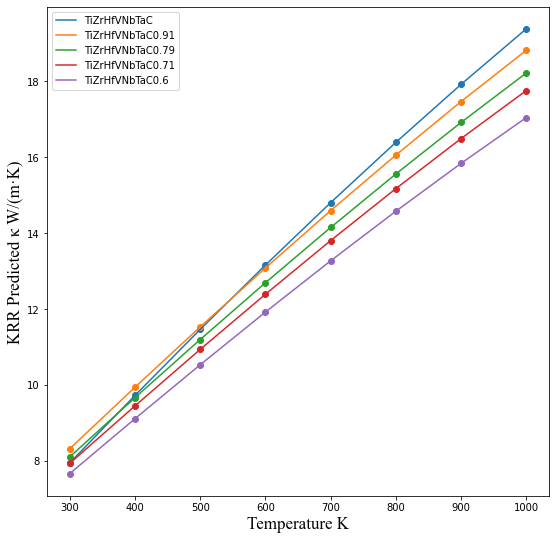

In [123]:
composition_order = ['TiZrHfVNbTaC', 'TiZrHfVNbTaC0.91', 'TiZrHfVNbTaC0.79', 'TiZrHfVNbTaC0.71', 'TiZrHfVNbTaC0.6']
plt.figure(figsize=(9, 9))
# Iterate over the compositions in the desired order
for composition in composition_order:
    # Filter the data for the current composition
    composition_data = data_test[data_test['composition'] == composition]
    
    # Extract the values for actual thermal conductivity and temperature
    krr_prediction = composition_data['krr_prediction']
    temperature = composition_data['temperature']
    plt.scatter(temperature, krr_prediction, label='krr prediction')
    # Plot the actual thermal conductivity vs. temperature and set the label
    plt.plot(temperature, krr_prediction, label=composition)

# Add labels and legend to the graph
plt.xlabel('Temperature K', fontproperties=FP)
plt.ylabel('KRR Predicted κ W/(m·K)', fontproperties=FP)

# Set the desired order for the legend labels
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [label for label in composition_order if label in labels]
plt.legend(handles, new_labels)

# Show the plot
plt.show()